# PROJECT #3 – VISUALIZE  
**Client: Federal Highway Administration (FHWA)**  

This notebook analyzes transportation data using:
- NHTS dataset (travel + vehicle characteristics)
- NGSIM dataset (vehicle trajectories)

We will:
- Clean and explore the data
- Create required visualizations
- Perform an IDM simulation
- Analyze driving behavior

In [4]:
# bring in pandas so we can work with tables of data
import pandas as pd

# numpy helps with math and calculations
import numpy as np

# matplotlib is used to build graphs
import matplotlib.pyplot as plt

# seaborn makes the graphs look cleaner
import seaborn as sns

# set a nice default style for all plots
sns.set_theme(style="whitegrid")

# make plots a good size so they are easy to read
plt.rcParams["figure.figsize"] = (10, 6)

## Load the Data

In this section, the two CSV files are loaded into Python as dataframes.

- `NHTS.csv` contains household and vehicle information
- `NGSIM (2).csv` contains vehicle trajectory data

Loading the data first allows the rest of the analysis to be performed.

In [5]:
# load the NHTS dataset
nhts_df = pd.read_csv("NHTS.csv")

# load the NGSIM dataset (fixed file name)
ngsim_df = pd.read_csv("NGSIM.csv")

# print out the size of each dataset to make sure they loaded correctly
print("NHTS shape:", nhts_df.shape)
print("NGSIM shape:", ngsim_df.shape)

NHTS shape: (14684, 23)
NGSIM shape: (8166, 8)


## Look at the Data

Before doing anything else, we take a quick look at the datasets.

This helps us understand:
- what columns exist
- what kind of data we are working with
- what we can use for our graphs

In [6]:
# print out all column names so we know what variables we have
print("NHTS columns:")
print(nhts_df.columns.tolist())

print("\nNGSIM columns:")
print(ngsim_df.columns.tolist())

# show the first few rows of each dataset
display(nhts_df.head())
display(ngsim_df.head())

NHTS columns:
['household_id', 'census_division', 'census_region', 'driver_count', 'household_income', 'household_size', 'household_workers', 'home_type', 'household_location', 'number_adults_household', 'vehicles_per_household', 'travel_date', 'travel_day', 'urban', 'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial', 'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year']

NGSIM columns:
['Time', 'leader_position(m)', 'follower_position(m)', 'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)', 'follower_acc(m/s^2)', 'trajectory_number']


,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


## Clean the Data

Before making plots, we clean things up a bit.

We will:
- remove extra spaces from text columns
- sort the NGSIM data so each trajectory is in order
- create a spacing variable between vehicles

This makes everything easier to work with later.

In [7]:
# go through each column in NHTS and clean up text columns
for col in nhts_df.columns:
    if nhts_df[col].dtype == "object":
        nhts_df[col] = nhts_df[col].astype(str).str.strip()

# sort NGSIM by trajectory and time so everything is in the right order
ngsim_df = ngsim_df.sort_values(["trajectory_number", "Time"]).reset_index(drop=True)

# create a new column that measures distance between leader and follower
ngsim_df["spacing(m)"] = ngsim_df["leader_position(m)"] - ngsim_df["follower_position(m)"]

## Bar Chart – Vehicle Type

This graph shows how many vehicles fall into each vehicle type category.

This gives a quick idea of what kinds of vehicles are most common in the dataset.

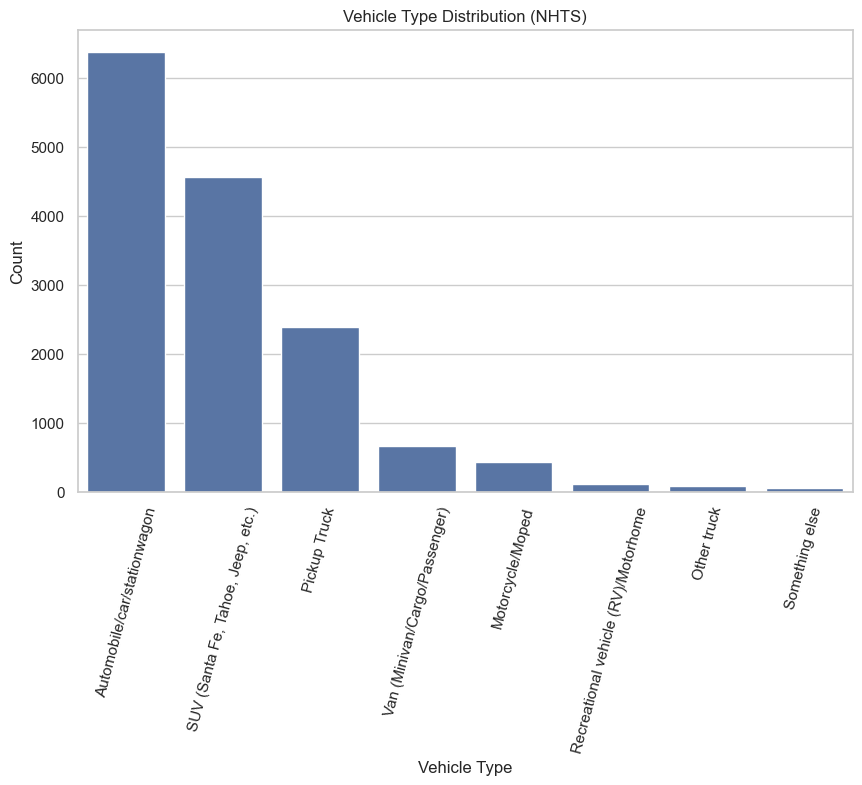

In [10]:
# count how many times each vehicle type appears
vehicle_counts = nhts_df["vehicle_type"].value_counts()

# create a bar chart using those counts
sns.barplot(x=vehicle_counts.index, y=vehicle_counts.values)

# label the graph so it is clear what it shows
plt.title("Vehicle Type Distribution (NHTS)")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")

# rotate labels so they don’t overlap
plt.xticks(rotation=75)

# show the graph
plt.show()

## Histogram – Vehicle Age

This histogram shows how vehicle ages are spread out.

It helps answer:
- are most vehicles newer or older?
- how wide the age range is

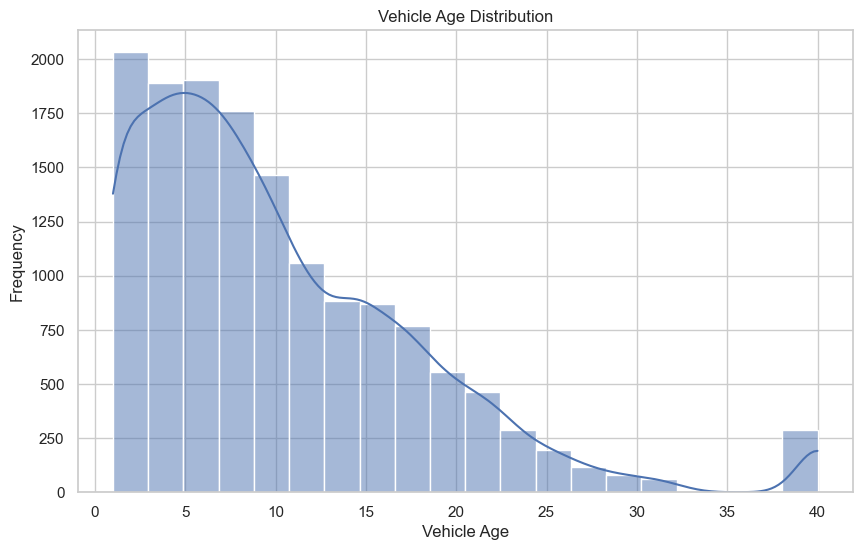

In [11]:
# build a histogram of vehicle age
sns.histplot(nhts_df["vehicle_age"], bins=20, kde=True)

# label everything clearly
plt.title("Vehicle Age Distribution")
plt.xlabel("Vehicle Age")
plt.ylabel("Frequency")

# display the plot
plt.show()

## Boxplot – Vehicle Age by Fuel Type

This compares vehicle age across different fuel types.

This helps show if certain fuel types (like electric or hybrid) tend to be newer.

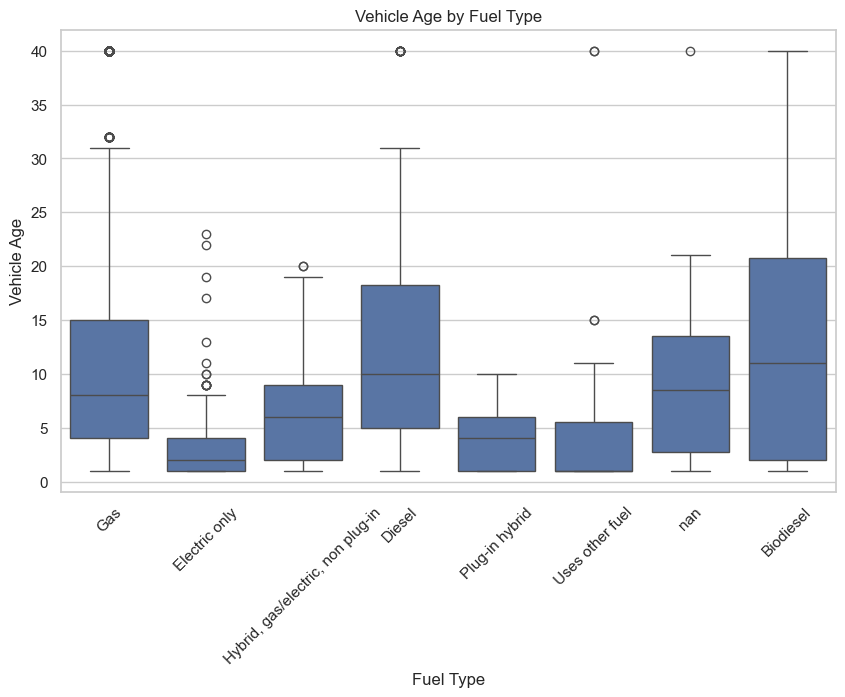

In [12]:
# create a boxplot comparing age across fuel types
sns.boxplot(data=nhts_df, x="fuel_type", y="vehicle_age")

# add labels and title
plt.title("Vehicle Age by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Vehicle Age")

# rotate labels for readability
plt.xticks(rotation=45)

# show the plot
plt.show()

## Choose One Trajectory

The NGSIM dataset has many trajectories, so we pick one to analyze.

This lets us clearly see how one leader and follower behave over time.

In [13]:
# select one trajectory (you can change this number if needed)
traj = ngsim_df[ngsim_df["trajectory_number"] == 4].copy()

# show how many rows we are working with
print("Rows in this trajectory:", len(traj))

# preview the data
display(traj.head())

Rows in this trajectory: 826


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number,spacing(m)
1722,0.1,49.373,0.0000,12.805,13.716,3.048000e-02,-0.03048,4,49.3730
1723,0.2,50.654,1.3716,12.808,13.713,-3.048000e-02,0.03048,4,49.2824
1724,0.3,51.935,2.7429,12.805,13.716,3.048000e-02,0.03048,4,49.1921
1725,0.4,53.215,4.1145,12.808,13.719,0.000000e+00,-0.51816,4,49.1005
1726,0.5,54.496,5.4864,12.808,13.667,7.110000e-13,0.24384,4,49.0096


## Time Series – Leader Speed

This shows how the leader vehicle’s speed changes over time.

This helps visualize how the front vehicle is moving.

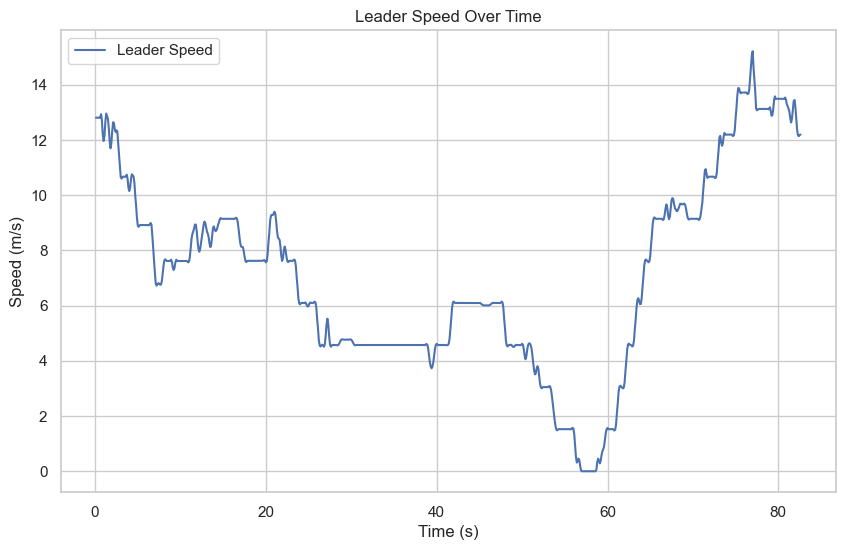

In [14]:
# plot leader speed over time
plt.plot(traj["Time"], traj["leader_speed(m/s)"], label="Leader Speed")

# label the graph
plt.title("Leader Speed Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")

# show legend and plot
plt.legend()
plt.show()

## Time Series – Follower Speed

This shows how the follower responds over time.

Comparing this with the leader helps show driving behavior.

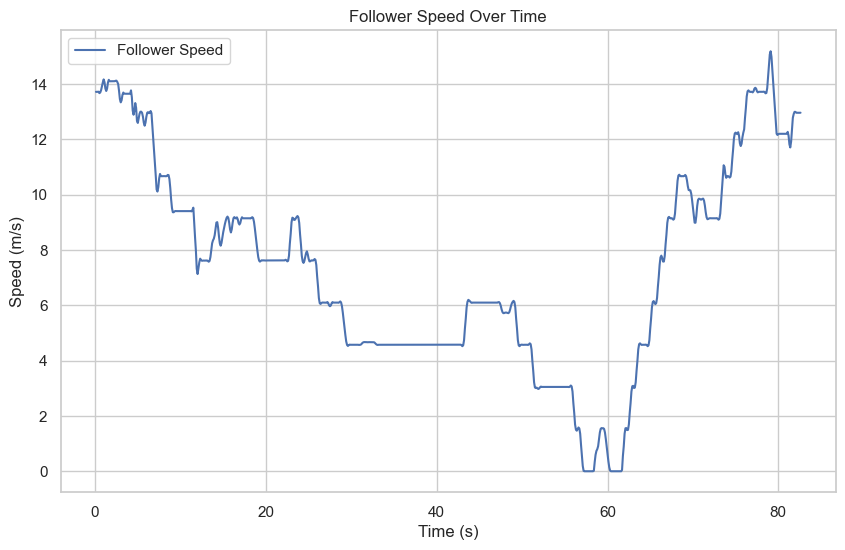

In [15]:
# plot follower speed over time
plt.plot(traj["Time"], traj["follower_speed(m/s)"], label="Follower Speed")

# label the graph
plt.title("Follower Speed Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")

# show legend and plot
plt.legend()
plt.show()

## Customized Plot

This compares leader and follower speed on the same graph.

This also shows customization (line styles, grid, etc.).

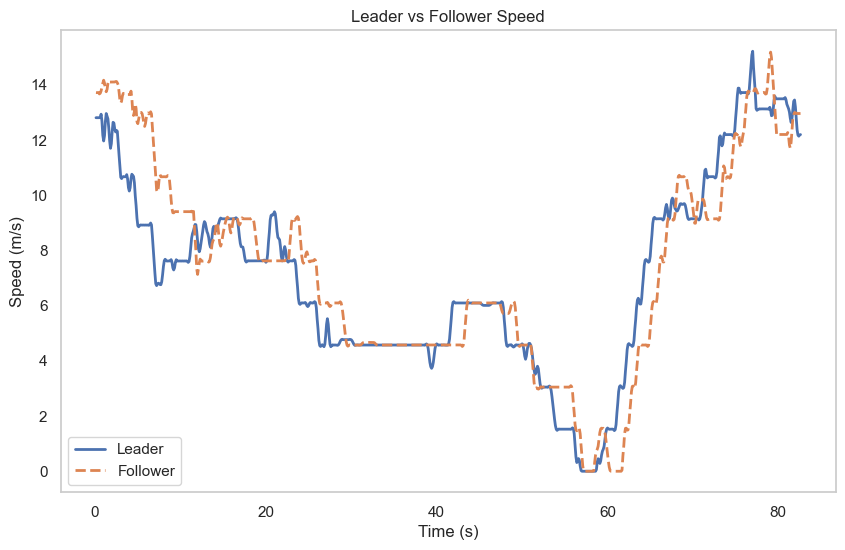

In [16]:
# plot both leader and follower speeds together
plt.plot(traj["Time"], traj["leader_speed(m/s)"], linewidth=2, label="Leader")
plt.plot(traj["Time"], traj["follower_speed(m/s)"], linestyle="--", linewidth=2, label="Follower")

# add labels and title
plt.title("Leader vs Follower Speed")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")

# add grid and legend
plt.grid()
plt.legend()

# show the plot
plt.show()

## IDM Simulation

Now we simulate follower behavior using the Intelligent Driver Model.

This model uses:
- spacing between vehicles
- speed difference
- driver reaction parameters

We will compare simulated results to real data.

In [19]:
# function that runs the IDM simulation
def idm_sim(data, a=1.5, b=1.0, v0=25, T=1.5, s0=2, delta=4):

    data = data.reset_index(drop=True)

    t = data["Time"].values
    leader_x = data["leader_position(m)"].values
    leader_v = data["leader_speed(m/s)"].values

    sim_x = np.zeros(len(data))
    sim_v = np.zeros(len(data))
    sim_a = np.zeros(len(data))

    # start with the real follower starting point
    sim_x[0] = data["follower_position(m)"].iloc[0]
    sim_v[0] = data["follower_speed(m/s)"].iloc[0]

    dt = np.mean(np.diff(t))

    for i in range(len(data)-1):

        # calculate spacing and speed difference
        gap = max(leader_x[i] - sim_x[i], 0.1)
        dv = sim_v[i] - leader_v[i]

        # desired spacing
        s_star = s0 + max(0, sim_v[i]*T + (sim_v[i]*dv)/(2*np.sqrt(a*b)))

        # IDM acceleration equation
        acc = a*(1 - (sim_v[i]/v0)**delta - (s_star/gap)**2)

        # update motion
        sim_a[i] = acc
        sim_v[i+1] = max(0, sim_v[i] + acc*dt)
        sim_x[i+1] = sim_x[i] + sim_v[i]*dt

    data["sim_acc"] = sim_a
    return data

In [18]:
# run the IDM simulation on the selected trajectory
idm_data = idm_sim(traj)

## IDM Results

This graph compares:
- leader acceleration
- actual follower acceleration
- simulated follower acceleration

This shows how close the model is to real driving behavior.